# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Lucas Lee



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline


# 1. Business Understanding
**Goal:** Build a model that predicts the resale price of HDB flats in Singapore's East Region (Bedok, Pasir Ris, Tampines) based on flat characteristics (location, size, storey, flat type, remaining lease, etc.).

**Business context:** Home buyers, sellers, and property agents in the East Region currently rely on manual comparison of past transactions to estimate a fair resale price. This is slow, inconsistent, and easy to get wrong, especially for buyers without market experience. A data-driven price estimator lets a user get an instant, defensible price estimate for a flat based on its actual attributes, giving them a stronger negotiating position and saving research time.

**Why this is a regression problem:** The target variable, `resale_price`, is a continuous numeric value (Singapore dollars), so this is framed as a **regression** task rather than classification. There is no natural business reason to bucket price into categories here — the actual dollar estimate is what has value to a buyer or seller.

**Scope:** The dataset is restricted to the three East Region towns present in the source data: Bedok, Pasir Ris, and Tampines (Changi and Paya Lebar are part of the URA East Region but are not HDB residential towns, so they do not appear in the dataset).

# 2. Data Understanding

## 2.1 Load dataset

In [ ]:
## Read *.csv file into pandas DataFrame
df_raw = pd.read_csv(r"ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")

print(f"Raw shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# Scope to East Region towns
east_towns = ['BEDOK', 'PASIR RIS', 'TAMPINES']
df = df_raw[df_raw['town'].isin(east_towns)].reset_index(drop=True)

print(f"Filtered to East Region: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Raw shape: 234316 rows, 11 columns
Filtered to East Region: 35060 rows, 11 columns


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,BEDOK,2 ROOM,101,BEDOK NTH AVE 4,04 TO 06,45.0,Improved,1978,60 years 06 months,238000.0
1,2017-01,BEDOK,3 ROOM,548,BEDOK NTH AVE 1,04 TO 06,68.0,New Generation,1980,62 years 06 months,272000.0
2,2017-01,BEDOK,3 ROOM,75,BEDOK NTH RD,07 TO 09,59.0,Improved,1978,60 years,278000.0
3,2017-01,BEDOK,3 ROOM,550,BEDOK NTH AVE 1,01 TO 03,68.0,New Generation,1980,62 years 05 months,280000.0
4,2017-01,BEDOK,3 ROOM,1,BEDOK STH AVE 1,01 TO 03,59.0,Improved,1976,58 years,280000.0


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35060 entries, 0 to 35059
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                35060 non-null  object 
 1   town                 35060 non-null  object 
 2   flat_type            35060 non-null  object 
 3   block                35060 non-null  object 
 4   street_name          35060 non-null  object 
 5   storey_range         35060 non-null  object 
 6   floor_area_sqm       35060 non-null  float64
 7   flat_model           35060 non-null  object 
 8   lease_commence_date  35060 non-null  int64  
 9   remaining_lease      35060 non-null  object 
 10  resale_price         35060 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 2.9+ MB


In [4]:
## Check for missing data
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
month,0,0.0
town,0,0.0
flat_type,0,0.0
block,0,0.0
street_name,0,0.0
storey_range,0,0.0
floor_area_sqm,0,0.0
flat_model,0,0.0
lease_commence_date,0,0.0
remaining_lease,0,0.0


In [5]:
## Describe data distribution
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,35060.000000,35060.000000,3.506000e+04
mean,102.094695,1991.454107,5.449122e+05
std,25.952596,11.755548,1.748640e+05
min,38.000000,1972.000000,1.500000e+05
25%,82.000000,1984.000000,4.100000e+05
50%,104.000000,1988.000000,5.220000e+05
75%,122.000000,1996.000000,6.600000e+05
max,193.000000,2022.000000,1.400000e+06


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

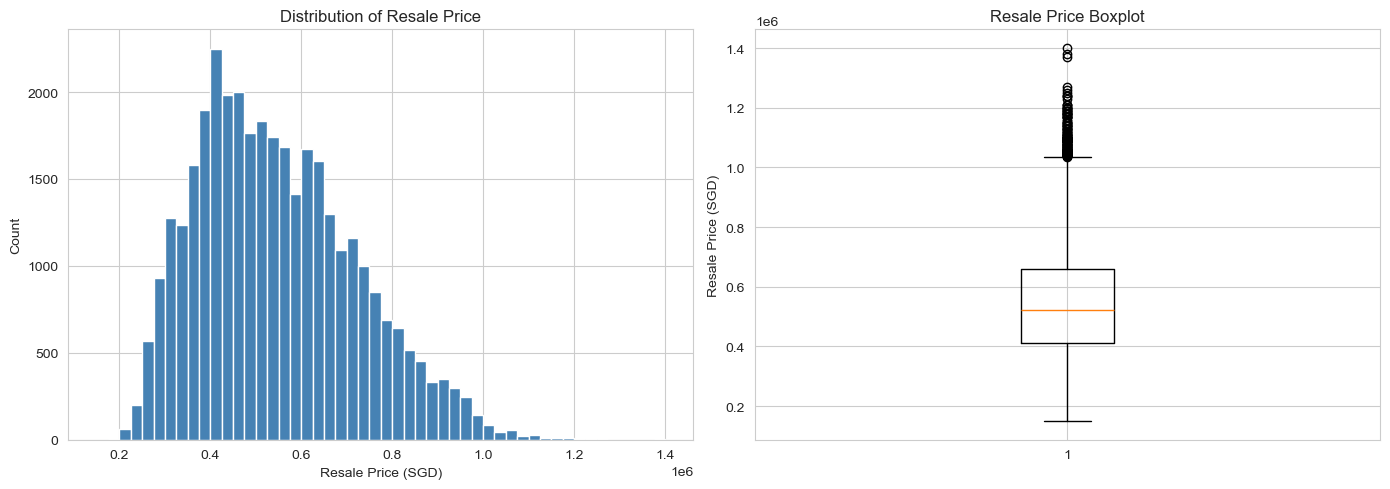

Skewness: 0.56
Median: $522,000  |  Mean: $544,912


In [6]:
## Understanding distribution of target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['resale_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Resale Price')
axes[0].set_xlabel('Resale Price (SGD)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['resale_price'], vert=True)
axes[1].set_title('Resale Price Boxplot')
axes[1].set_ylabel('Resale Price (SGD)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['resale_price'].skew():.2f}")
print(f"Median: ${df['resale_price'].median():,.0f}  |  Mean: ${df['resale_price'].mean():,.0f}")

**Observations:**
- Resale price is right skewed with a skewness of 0.56, with most transactions between $300,000 and $700,000 and a median of $522,000.
- There's a long tail of high value transactions up to $1.4 million, with the boxplot showing outliers above roughly $1.03 million.
- The skew suggests tree based models (Random Forest, Gradient Boosting) may handle this target better out of the box than Linear Regression, which assumes a more symmetric error distribution. We may also test a log transform of the target during modelling.

### 2.3.1.2 Understanding distribution of features

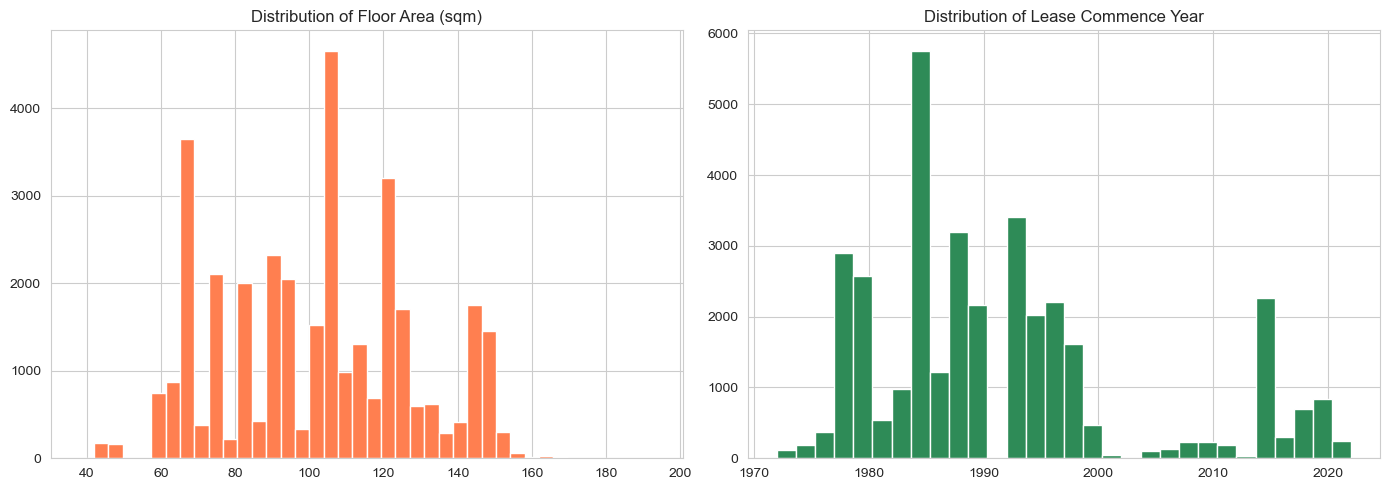

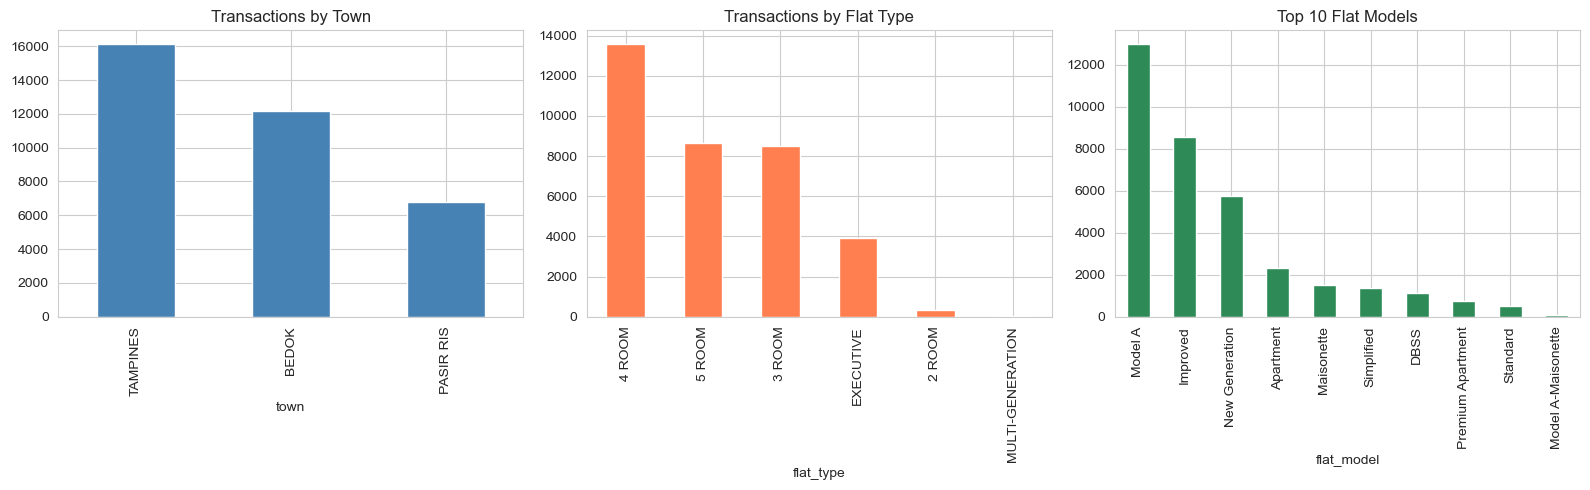

In [7]:
## Understanding distribution of features

# Numeric features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['floor_area_sqm'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Distribution of Floor Area (sqm)')
axes[1].hist(df['lease_commence_date'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution of Lease Commence Year')
plt.tight_layout()
plt.show()

# Categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df['town'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transactions by Town')

df['flat_type'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Transactions by Flat Type')

df['flat_model'].value_counts().head(10).plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Top 10 Flat Models')

plt.tight_layout()
plt.show()

**Observations:**
- Floor area is multimodal, with distinct peaks around 65 to 70 sqm, 90 sqm, 105 to 110 sqm, and 145 sqm. This lines up with standard HDB flat type sizes (3 room, 4 room, 5 room, executive) rather than a smooth continuous spread.
- Lease commence year is also multimodal, with major peaks around 1978 to 1985 and 1993 to 1997, and a smaller spike around 2015. This reflects distinct waves of HDB development in the East Region rather than steady year on year construction.
- Tampines has the most transactions (about 16,000), followed by Bedok (about 12,000), then Pasir Ris (about 6,800). This uneven split means the model will likely be more reliable for Tampines and Bedok predictions than Pasir Ris, simply due to more training examples.
- 4 room flats dominate transactions, followed by 5 room and 3 room in similar numbers, then executive. 2 room and multi generation flats are rare in this data, so predictions for those flat types will be less reliable.

### 2.3.2 Understanding relationship between variables

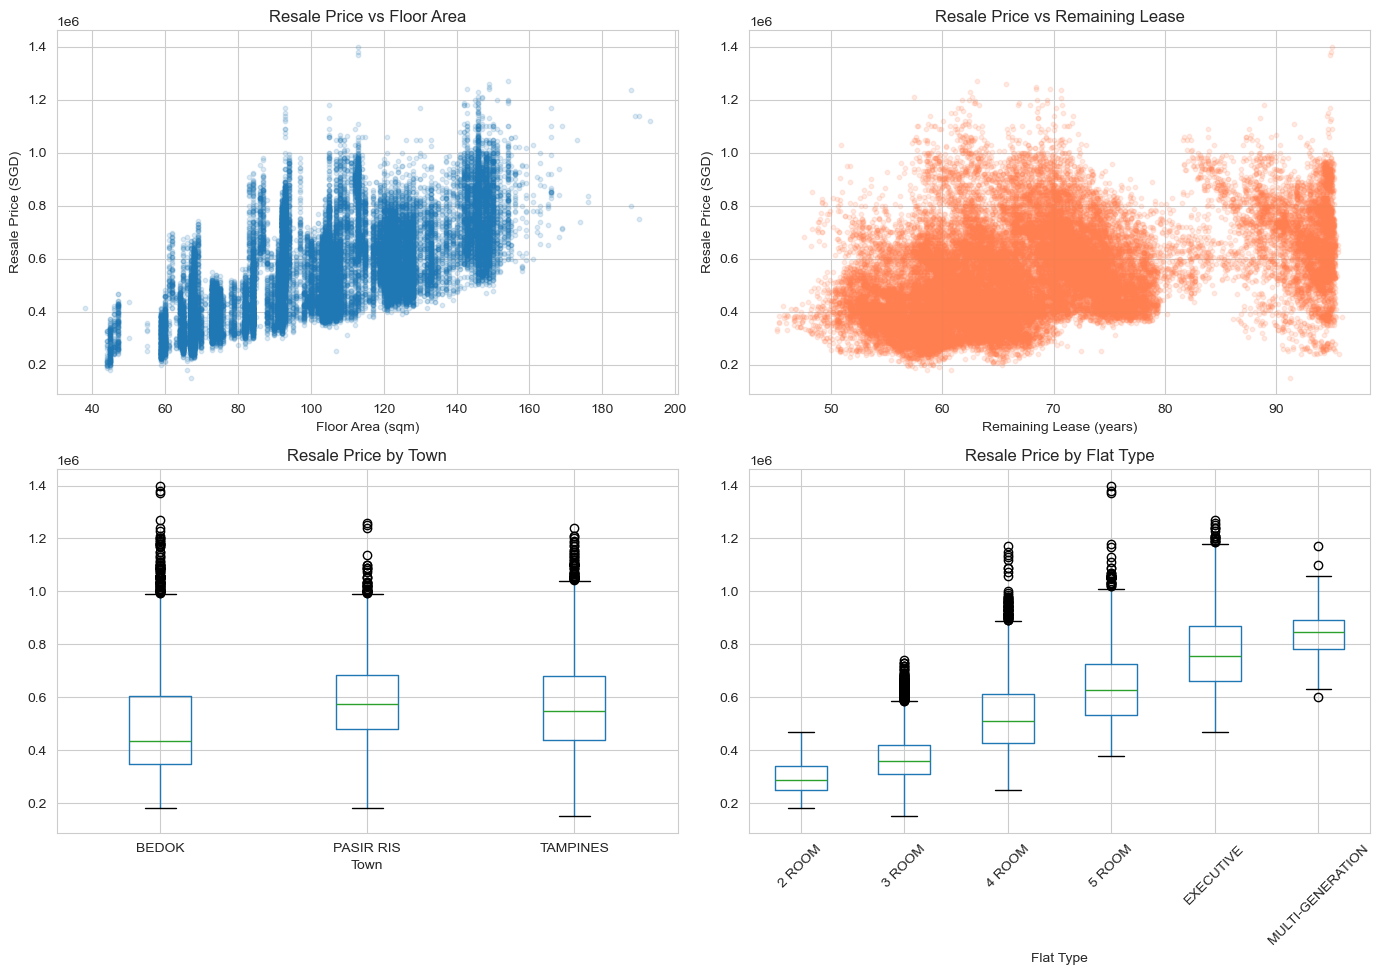

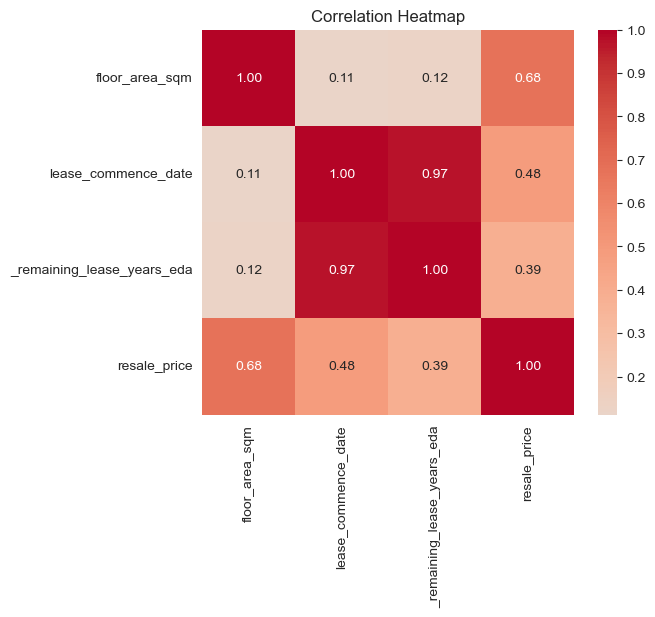

In [8]:
## Understanding relationship between variables

# numeric parse of remaining_lease just for plotting
def parse_lease_years(text):
    parts = text.split()
    years = int(parts[0])
    months = int(parts[2]) if 'month' in text else 0
    return years + months / 12

df['_remaining_lease_years_eda'] = df['remaining_lease'].apply(parse_lease_years)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(df['floor_area_sqm'], df['resale_price'], alpha=0.15, s=10)
axes[0,0].set_title('Resale Price vs Floor Area')
axes[0,0].set_xlabel('Floor Area (sqm)')
axes[0,0].set_ylabel('Resale Price (SGD)')

axes[0,1].scatter(df['_remaining_lease_years_eda'], df['resale_price'], alpha=0.15, s=10, color='coral')
axes[0,1].set_title('Resale Price vs Remaining Lease')
axes[0,1].set_xlabel('Remaining Lease (years)')
axes[0,1].set_ylabel('Resale Price (SGD)')

df.boxplot(column='resale_price', by='town', ax=axes[1,0])
axes[1,0].set_title('Resale Price by Town')
axes[1,0].set_xlabel('Town')
plt.sca(axes[1,0])
plt.xticks(rotation=0)

df.boxplot(column='resale_price', by='flat_type', ax=axes[1,1])
axes[1,1].set_title('Resale Price by Flat Type')
axes[1,1].set_xlabel('Flat Type')
plt.sca(axes[1,1])
plt.xticks(rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features
numeric_cols = ['floor_area_sqm', 'lease_commence_date', '_remaining_lease_years_eda', 'resale_price']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Drop the temp column
df.drop(columns=['_remaining_lease_years_eda'], inplace=True)

**Observations:**
- Floor area shows the clearest relationship with resale price, a strong positive trend, though the spread widens at larger floor areas (bigger flats have more price variation, likely due to flat model and finishing differences).
- Remaining lease shows a much weaker, noisier relationship with price on its own. This is likely because remaining lease is highly correlated with lease commence date (0.97 correlation, seen in the heatmap), so its effect on price is probably being absorbed by other variables like town and flat type rather than acting independently.
- Bedok has a noticeably lower median resale price (~$440,000) than Pasir Ris and Tampines (~$550,000 to $580,000), which is a useful signal that town should be a meaningful feature in the model.
- Resale price increases monotonically with flat type, from 2 room through to multi generation and executive, which is expected but confirms flat type is a strong predictor.
- The correlation heatmap confirms floor_area_sqm has the strongest linear relationship with resale_price (0.68), followed by lease_commence_date (0.48) and remaining_lease (0.39). Importantly, lease_commence_date and remaining_lease are almost perfectly correlated with each other (0.97), which is expected since one is basically derived from the other. This is a multicollinearity flag: in Section 3, we should likely keep only one of these two, not both, to avoid redundant features.

# 3. Data Preparation

## 3.1 Data Cleaning

In [9]:
## Clean data

# Parse remaining_lease text into a numeric years value
def parse_lease_years(text):
    parts = text.split()
    years = int(parts[0])
    months = int(parts[2]) if 'month' in text else 0
    return years + months / 12

df['remaining_lease_years'] = df['remaining_lease'].apply(parse_lease_years)

# Convert storey_range (e.g. "10 TO 12") into a single numeric midpoint
def parse_storey_midpoint(text):
    low, high = text.split(' TO ')
    return (int(low) + int(high)) / 2

df['storey_mid'] = df['storey_range'].apply(parse_storey_midpoint)

# Pull transaction year and month out of the month column
# Transaction year matters since HDB prices have trended upward over time
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df['txn_year'] = df['month'].dt.year
df['txn_month'] = df['month'].dt.month

# Drop columns we don't need going forward
# lease_commence_date is dropped: the EDA heatmap showed it's almost perfectly
# correlated with remaining_lease_years (0.97), so keeping both is redundant.
# remaining_lease_years is kept since it's more directly meaningful to a buyer.
# block and street_name are dropped: too many unique values to generalise well,
# and we don't have extra data (like MRT distance) to turn them into something useful.
# remaining_lease, storey_range and month are dropped since we've replaced them
# with cleaner numeric versions above.
df_clean = df.drop(columns=['lease_commence_date', 'block', 'street_name',
                             'remaining_lease', 'storey_range', 'month'])

print(f"Shape after cleaning: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
df_clean.head()

Shape after cleaning: 35060 rows, 9 columns


,town,flat_type,floor_area_sqm,flat_model,resale_price,remaining_lease_years,storey_mid,txn_year,txn_month
0,BEDOK,2 ROOM,45.0,Improved,238000.0,60.500000,5.0,2017,1
1,BEDOK,3 ROOM,68.0,New Generation,272000.0,62.500000,5.0,2017,1
2,BEDOK,3 ROOM,59.0,Improved,278000.0,60.000000,8.0,2017,1
3,BEDOK,3 ROOM,68.0,New Generation,280000.0,62.416667,2.0,2017,1
4,BEDOK,3 ROOM,59.0,Improved,280000.0,58.000000,2.0,2017,1


In [10]:
## Check for duplicates and confirm cleaning worked
print(f"Duplicate rows: {df_clean.duplicated().sum()}")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")
df_clean.info()

Duplicate rows: 110
Total missing values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35060 entries, 0 to 35059
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   town                   35060 non-null  object 
 1   flat_type              35060 non-null  object 
 2   floor_area_sqm         35060 non-null  float64
 3   flat_model             35060 non-null  object 
 4   resale_price           35060 non-null  float64
 5   remaining_lease_years  35060 non-null  float64
 6   storey_mid             35060 non-null  float64
 7   txn_year               35060 non-null  int32  
 8   txn_month              35060 non-null  int32  
dtypes: float64(4), int32(2), object(3)
memory usage: 2.1+ MB


**Data cleaning decisions and assumptions:**
- Outliers in resale_price (transactions above ~$1.03 million seen in the EDA boxplot) are kept rather than removed. These appear to be legitimate high value transactions (larger flats, higher floors, better located blocks) rather than data entry errors, so removing them would throw away real market signal.
- No missing values remain after cleaning, so no imputation was needed.
- Categorical variables (town, flat_type, flat_model) are not yet encoded here. Encoding is deferred to the modelling pipeline in Section 4, so that encoding is fit only on the training set and not leaked from the test set.

In [11]:
## Check if these are true duplicate transactions or just coincidental matches
# Check duplicates BEFORE block and street_name were dropped
original_cols_check = df.duplicated(subset=[c for c in df.columns if c not in
                                             ['remaining_lease_years', 'storey_mid',
                                              'txn_year', 'txn_month']]).sum()

print(f"Duplicates with block/street_name still included: {original_cols_check}")
print(f"Duplicates after dropping block/street_name: {df_clean.duplicated().sum()}")

Duplicates with block/street_name still included: 38
Duplicates after dropping block/street_name: 110


In [12]:
## Drop true duplicate transactions (identical even in block and street_name)
true_dupe_mask = df.duplicated(subset=[c for c in df.columns if c not in
                                         ['remaining_lease_years', 'storey_mid',
                                          'txn_year', 'txn_month']])

df_clean = df_clean[~true_dupe_mask.values].reset_index(drop=True)

print(f"Dropped {true_dupe_mask.sum()} true duplicate rows")
print(f"Shape after dropping true duplicates: {df_clean.shape[0]} rows")
print(f"Remaining duplicates (coincidental matches, kept): {df_clean.duplicated().sum()}")

Dropped 38 true duplicate rows
Shape after dropping true duplicates: 35022 rows
Remaining duplicates (coincidental matches, kept): 72


**On duplicate rows:**
110 duplicate rows appear after dropping block and street_name. Checking against
the original data (including block and street_name) shows these split into two
groups. 38 rows are exact duplicates even with block and street_name included,
meaning every field matches down to the specific unit. It is highly unlikely two
genuinely different transactions would match on every single field, so these are
treated as duplicate records in the source data and dropped.

The remaining 72 rows only become duplicates after block and street_name are
removed, meaning they are different flats that happen to share identical values
across every feature kept for modelling (same town, flat type, floor area, flat
model, storey range, lease, and transaction month/price). These represent real,
distinct sales and are kept, since each one is genuine market data and dropping
them would bias the model against common, "typical" flat configurations.

## 3.2 Handling Categorical Data (One-Hot Encoding)

In [13]:
## Check datatypes for each column
col_categorical = df_clean.select_dtypes(include=['object']).columns  ## Select all categorical columns

## Identify the columns for features (X) and target (y)
y = df_clean['resale_price']  ## Select target column
X = df_clean.drop(columns=['resale_price'])  ## Select feature columns

## One-Hot Encoding
X = pd.get_dummies(X,
                    columns=col_categorical,
                    drop_first=True  ## Remove redundant information
                    )
X

,floor_area_sqm,remaining_lease_years,storey_mid,txn_year,txn_month,town_PASIR RIS,town_TAMPINES,flat_type_3 ROOM,flat_type_4 ROOM,flat_type_5 ROOM,flat_type_EXECUTIVE,flat_type_MULTI-GENERATION,flat_model_3Gen,flat_model_Adjoined flat,flat_model_Apartment,flat_model_DBSS,flat_model_Improved,flat_model_Maisonette,flat_model_Model A,flat_model_Model A-Maisonette,flat_model_Multi Generation,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Maisonette,flat_model_Simplified,flat_model_Standard
0,45.0,60.500000,5.0,2017,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,68.0,62.500000,5.0,2017,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,59.0,60.000000,8.0,2017,1,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,68.0,62.416667,2.0,2017,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,59.0,58.000000,2.0,2017,1,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35017,146.0,60.750000,2.0,2026,6,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
35018,149.0,62.166667,2.0,2026,1,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
35019,146.0,62.166667,2.0,2026,1,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
35020,146.0,62.000000,8.0,2026,2,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


## 3.3 Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

## Split data into train set and test set
test_size = 0.3
random_state = 2026  ## For reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,
                                                       y,
                                                       test_size=test_size,
                                                       random_state=random_state)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Train set: 24515 rows
Test set: 10507 rows


**Train-test split rationale:**
Categorical features (town, flat_type, flat_model) are one-hot encoded using
`pd.get_dummies()` with `drop_first=True`, converting them into binary columns
before the split. A 70/30 train-test split is then applied, giving about 24,500
training rows and 10,500 test rows. `random_state=2026` is set for reproducibility.

# 4. Modelling

### 4.1 Baseline Model


In [15]:
## Baseline model: predicts the mean price every time, no real learning happens
## This gives us a floor to prove our actual models are doing something useful
from sklearn.dummy import DummyRegressor

baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train, y_train)

print("Baseline model trained (predicts mean training price for every input)")
print(f"Mean training price: ${y_train.mean():,.0f}")

Baseline model trained (predicts mean training price for every input)
Mean training price: $544,194


### 4.2 Train Model

In [16]:
## Initialise and train model
## Training three different algorithm types so we can compare how they handle
## this data: a simple linear model, and two tree based ensemble models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained")

rf_model = RandomForestRegressor(random_state=2026)
rf_model.fit(X_train, y_train)
print("Random Forest trained")

gb_model = GradientBoostingRegressor(random_state=2026)
gb_model.fit(X_train, y_train)
print("Gradient Boosting trained")

Linear Regression trained
Random Forest trained
Gradient Boosting trained


# 5. Model Evaluation

In [17]:
## Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_model(baseline_model, X_test, y_test, 'Baseline (mean)'))
results.append(evaluate_model(lr_model, X_test, y_test, 'Linear Regression'))
results.append(evaluate_model(rf_model, X_test, y_test, 'Random Forest'))
results.append(evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting'))

results_df = pd.DataFrame(results)
results_df['MAE'] = results_df['MAE'].round(0)
results_df['RMSE'] = results_df['RMSE'].round(0)
results_df['R2'] = results_df['R2'].round(4)
results_df


,Model,MAE,RMSE,R2
0,Baseline (mean),144441.0,176713.0,-0.0002
1,Linear Regression,43986.0,57401.0,0.8945
2,Random Forest,25218.0,35163.0,0.9604
3,Gradient Boosting,30188.0,42095.0,0.9432


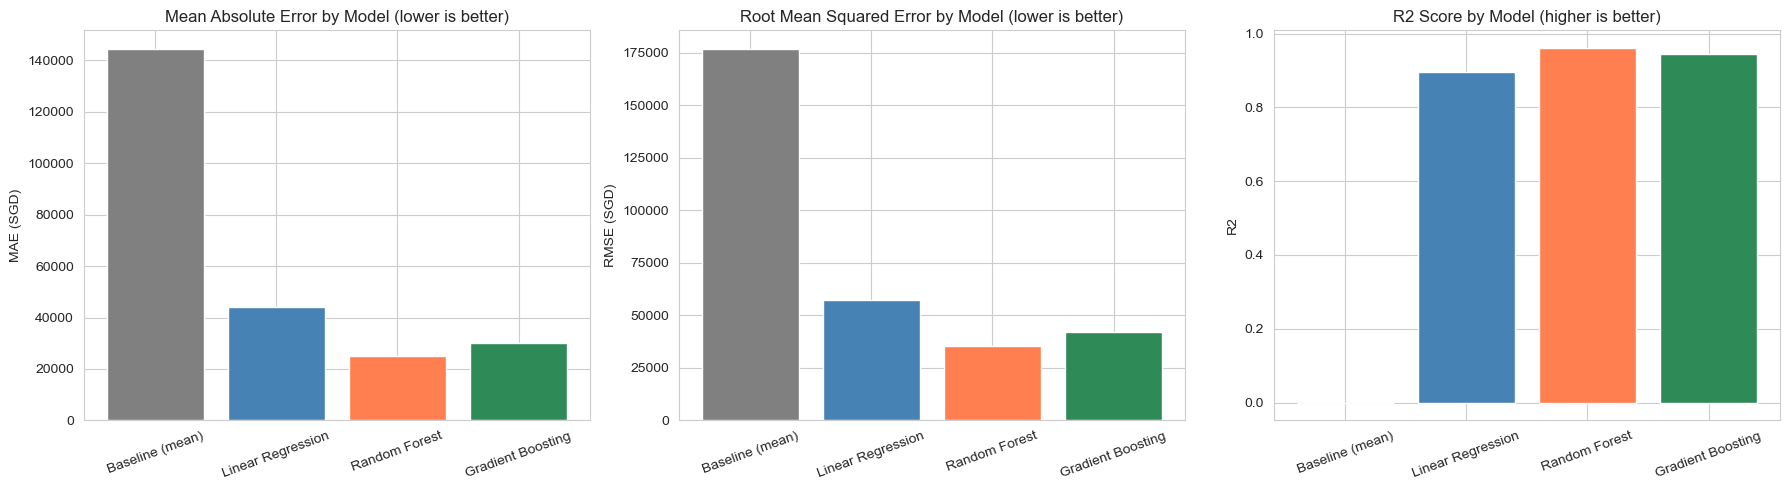

In [18]:
## Visual comparison of model performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(results_df['Model'], results_df['MAE'], color=['gray', 'steelblue', 'coral', 'seagreen'])
axes[0].set_title('Mean Absolute Error by Model (lower is better)')
axes[0].set_ylabel('MAE (SGD)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(results_df['Model'], results_df['RMSE'], color=['gray', 'steelblue', 'coral', 'seagreen'])
axes[1].set_title('Root Mean Squared Error by Model (lower is better)')
axes[1].set_ylabel('RMSE (SGD)')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(results_df['Model'], results_df['R2'], color=['gray', 'steelblue', 'coral', 'seagreen'])
axes[2].set_title('R2 Score by Model (higher is better)')
axes[2].set_ylabel('R2')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Metric selection and interpretation:**

Three metrics were computed above for a full initial comparison: MAE, RMSE, and R2.

Going forward, this project focuses on MAE (Mean Absolute Error) as the primary
metric, with R2 as a supporting metric. MAE gives the average price error in
actual dollars, which is directly meaningful to a buyer or seller using the app
("this estimate is typically off by about $X"). This is easier for a non
technical user to understand than a squared error metric like RMSE.

R2 is kept as a supporting metric, showing how much of the overall price
variance the model explains, a useful standardised way to compare model fit
across different model types.

RMSE is not tracked further after this point. While it was useful here to
confirm all three metrics agreed on Random Forest as the strongest model, RMSE's
main value (penalising large errors more heavily) overlaps with what MAE and R2
already capture together for this dataset, and tracking three metrics through
every later experiment would add noise without adding a meaningfully different
decision-making signal.

All models are compared against a baseline that always predicts the mean
training price, to confirm that any model we choose is actually adding real
predictive value, not just guessing close to average.

**Model Diversity, Comparison & Selection Rationale:**

Random Forest is selected as the best performing model. It has the lowest MAE
($25,218) of all models tested, meaning its price estimates are on average
closer to the true resale price. It also has the highest R2 (0.9604),
explaining the most variance in resale price.

All three trained models comfortably beat the baseline (MAE $144,441), confirming
they are genuinely learning useful patterns rather than guessing near the average.

Gradient Boosting performs reasonably close behind Random Forest (MAE $30,188 vs
$25,218) but does not surpass it here, likely because it was run with default,
untuned settings, boosting models are typically more sensitive to hyperparameters
than Random Forest. Random Forest is also generally more robust to the outliers
seen in the EDA boxplot, since each tree is trained on a bootstrapped sample and
averaged, reducing the influence of any single unusual transaction.

Linear Regression trails both tree based models by a wide margin (MAE $43,986),
which is expected given the EDA showed multimodal, non linear relationships
between features like floor_area_sqm and resale_price that a linear model
cannot capture well.

Random Forest is carried forward for further feature engineering and
hyperparameter tuning, based on this evidence.

## Iterative model development


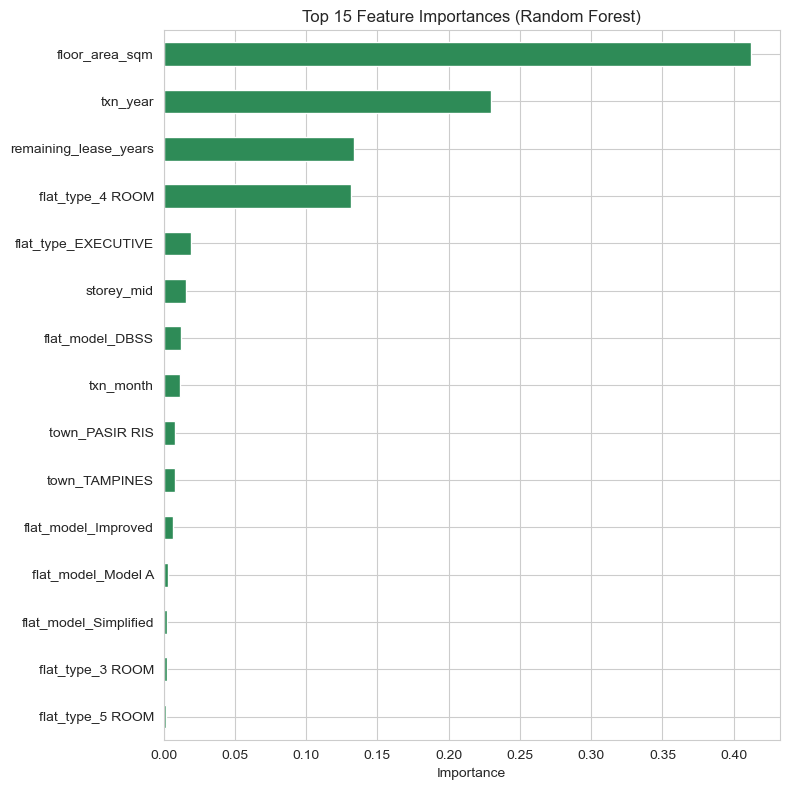

floor_area_sqm           0.411848
txn_year                 0.229828
remaining_lease_years    0.133438
flat_type_4 ROOM         0.131714
flat_type_EXECUTIVE      0.019153
storey_mid               0.015440
flat_model_DBSS          0.012062
txn_month                0.011317
town_PASIR RIS           0.007994
town_TAMPINES            0.007711
flat_model_Improved      0.006270
flat_model_Model A       0.003351
flat_model_Simplified    0.002646
flat_type_3 ROOM         0.002247
flat_type_5 ROOM         0.001872
dtype: float64

In [19]:
## Further feature engineering / feature selection
## Check feature importances from Random Forest to guide feature engineering
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh', color='seagreen')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances.head(15)

### Further feature engineering / feature selection

Based on feature importances from the first Random Forest, storey_mid showed
surprisingly low importance (0.015) despite floor level typically influencing
HDB resale price in Singapore. We test whether binning storey into Low/Mid/High
categories captures this relationship better than the raw numeric value.

In [20]:
## Feature engineering: bin storey_mid into categories
def storey_category(mid):
    if mid <= 6:
        return 'Low'
    elif mid <= 15:
        return 'Mid'
    else:
        return 'High'

df_clean['storey_category'] = df_clean['storey_mid'].apply(storey_category)

print(df_clean['storey_category'].value_counts())

storey_category
Mid     17380
Low     16873
High      769
Name: count, dtype: int64


In [21]:
## Full importance list, not just top 15
importances_full = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances_full.sort_values(ascending=False)

floor_area_sqm                   0.411848
txn_year                         0.229828
remaining_lease_years            0.133438
flat_type_4 ROOM                 0.131714
flat_type_EXECUTIVE              0.019153
storey_mid                       0.015440
flat_model_DBSS                  0.012062
txn_month                        0.011317
town_PASIR RIS                   0.007994
town_TAMPINES                    0.007711
flat_model_Improved              0.006270
flat_model_Model A               0.003351
flat_model_Simplified            0.002646
flat_type_3 ROOM                 0.002247
flat_type_5 ROOM                 0.001872
flat_model_Maisonette            0.000878
flat_model_Apartment             0.000863
flat_model_Premium Apartment     0.000416
flat_model_New Generation        0.000381
flat_model_Model A-Maisonette    0.000252
flat_model_Premium Maisonette    0.000072
flat_type_MULTI-GENERATION       0.000066
flat_model_Standard              0.000065
flat_model_Multi Generation      0

In [22]:
## Feature selection: identify one-hot columns with negligible importance (below 0.001)
low_importance_cols = importances_full[importances_full < 0.001].index.tolist()
print(f"Dropping {len(low_importance_cols)} low importance columns:")
print(low_importance_cols)

Dropping 11 low importance columns:
['flat_type_MULTI-GENERATION', 'flat_model_3Gen', 'flat_model_Adjoined flat', 'flat_model_Apartment', 'flat_model_Maisonette', 'flat_model_Model A-Maisonette', 'flat_model_Multi Generation', 'flat_model_New Generation', 'flat_model_Premium Apartment', 'flat_model_Premium Maisonette', 'flat_model_Standard']


In [23]:
## Rebuild feature set with storey_category instead of storey_mid,
## and without the negligible-importance flat_model/flat_type columns
col_categorical_v2 = ['town', 'flat_type', 'flat_model', 'storey_category']

y = df_clean['resale_price']
X_v2 = df_clean.drop(columns=['resale_price', 'storey_mid'])
X_v2 = pd.get_dummies(X_v2, columns=col_categorical_v2, drop_first=True)

# Only drop columns that still exist in this new version
cols_to_drop = [c for c in low_importance_cols if c in X_v2.columns]
X_v2 = X_v2.drop(columns=cols_to_drop)

print(f"Shape after feature engineering: {X_v2.shape[0]} rows, {X_v2.shape[1]} columns")
X_v2.head()

Shape after feature engineering: 35022 rows, 16 columns


,floor_area_sqm,remaining_lease_years,txn_year,txn_month,town_PASIR RIS,town_TAMPINES,flat_type_3 ROOM,flat_type_4 ROOM,flat_type_5 ROOM,flat_type_EXECUTIVE,flat_model_DBSS,flat_model_Improved,flat_model_Model A,flat_model_Simplified,storey_category_Low,storey_category_Mid
0,45.0,60.500000,2017,1,False,False,False,False,False,False,False,True,False,False,True,False
1,68.0,62.500000,2017,1,False,False,True,False,False,False,False,False,False,False,True,False
2,59.0,60.000000,2017,1,False,False,True,False,False,False,False,True,False,False,False,True
3,68.0,62.416667,2017,1,False,False,True,False,False,False,False,False,False,False,True,False
4,59.0,58.000000,2017,1,False,False,True,False,False,False,False,True,False,False,True,False


In [24]:
## Split the engineered feature set (same test_size and random_state as before, for a fair comparison)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_v2, y, test_size=test_size, random_state=random_state
)

In [35]:
## Retrain Random Forest on the engineered features and compare against the original
rf_model_v2 = RandomForestRegressor(random_state=2026)
rf_model_v2.fit(X_train2, y_train2)

results.append(evaluate_model(rf_model_v2, X_test2, y_test2, 'Random Forest (engineered)'))
results_df2 = pd.DataFrame(results)
results_df2['MAE'] = results_df2['MAE'].round(0)
results_df2['R2'] = results_df2['R2'].round(4)
results_df2 = results_df2.drop(columns=['RMSE'])
results_df2

,Model,MAE,R2
0,Baseline (mean),144441.0,-0.0002
1,Linear Regression,43986.0,0.8945
2,Random Forest,25218.0,0.9604
3,Gradient Boosting,30188.0,0.9432
4,Random Forest (engineered),26264.0,0.9570
5,Random Forest (columns dropped only),25431.0,0.9595
6,Random Forest (tuned),25199.0,0.9598
7,Random Forest (engineered),26264.0,0.9570


In [36]:
## Isolate the effect: drop low importance columns only, keep storey_mid as-is (no binning)
col_categorical_v3 = ['town', 'flat_type', 'flat_model']

X_v3 = df_clean.drop(columns=['resale_price', 'storey_category'])
X_v3 = pd.get_dummies(X_v3, columns=col_categorical_v3, drop_first=True)

cols_to_drop_v3 = [c for c in low_importance_cols if c in X_v3.columns]
X_v3 = X_v3.drop(columns=cols_to_drop_v3)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_v3, y, test_size=test_size, random_state=random_state
)

rf_model_v3 = RandomForestRegressor(random_state=2026)
rf_model_v3.fit(X_train3, y_train3)

results.append(evaluate_model(rf_model_v3, X_test3, y_test3, 'Random Forest (columns dropped only)'))
results_df3 = pd.DataFrame(results)
results_df3['MAE'] = results_df3['MAE'].round(0)
results_df3['R2'] = results_df3['R2'].round(4)
results_df3 = results_df3.drop(columns=['RMSE'])
results_df3

,Model,MAE,R2
0,Baseline (mean),144441.0,-0.0002
1,Linear Regression,43986.0,0.8945
2,Random Forest,25218.0,0.9604
3,Gradient Boosting,30188.0,0.9432
4,Random Forest (engineered),26264.0,0.9570
5,Random Forest (columns dropped only),25431.0,0.9595
6,Random Forest (tuned),25199.0,0.9598
7,Random Forest (engineered),26264.0,0.9570
8,Random Forest (columns dropped only),25431.0,0.9595


### Feature engineering / feature selection results

Two changes were tested against the original Random Forest baseline (MAE $25,218,
R2 0.9604):

1. Binning storey_mid into Low/Mid/High categories, combined with dropping columns
   with feature importance below 0.001. This performed worse (MAE $26,264, R2 0.9570).
2. Dropping the same low importance columns while keeping storey_mid as a continuous
   value. This performed nearly identically to the original (MAE $25,431, R2 0.9595),
   a difference of only $213 MAE.

This isolates the cause: binning storey_mid removed information Random Forest could
otherwise use to find its own optimal split points, while dropping the negligible
flat_model/flat_type dummy columns cost almost nothing.

**Decision:** the reduced feature set (low importance columns dropped, storey_mid
kept as continuous) is carried forward. It performs within noise of the full
feature set, but with a simpler, more interpretable model, fewer redundant
one-hot columns representing rare flat models that individually explain very
little price variance. This is preferred for a production tool, since a
simpler model is easier to maintain and less prone to overfitting on rare
categories as new data comes in.

In [27]:
## Confirm the feature set carried forward into hyperparameter tuning
X_final, X_train_final, X_test_final = X_v3, X_train3, X_test3
y_final, y_train_final, y_test_final = y, y_train3, y_test3

print(f"Final feature set: {X_final.shape[1]} columns")
print(list(X_final.columns))

Final feature set: 15 columns
['floor_area_sqm', 'remaining_lease_years', 'storey_mid', 'txn_year', 'txn_month', 'town_PASIR RIS', 'town_TAMPINES', 'flat_type_3 ROOM', 'flat_type_4 ROOM', 'flat_type_5 ROOM', 'flat_type_EXECUTIVE', 'flat_model_DBSS', 'flat_model_Improved', 'flat_model_Model A', 'flat_model_Simplified']


## Hyperparameter Tuning

In [28]:
## Define parameter grid (max 3 values per hyperparameter, as required)
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

## RandomizedSearchCV: samples 10 combinations from the 27 possible,
## using MAE as the scoring metric to match our chosen evaluation metric
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=2026,  ## For reproducibility
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_final, y_train_final)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...om_state=2026)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0

In [29]:
## Comparison logs: show all 10 tested combinations, ranked by performance
cv_log = pd.DataFrame(random_search.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_leaf',
     'mean_test_score', 'rank_test_score']
].sort_values('rank_test_score')

cv_log['mean_test_score'] = -cv_log['mean_test_score']  ## Flip sign back to positive MAE
cv_log.columns = ['n_estimators', 'max_depth', 'min_samples_leaf', 'cv_MAE', 'rank']
cv_log

,n_estimators,max_depth,min_samples_leaf,cv_MAE,rank
0,100,None,2,26474.671434,1
2,200,20,1,26483.098212,2
1,300,20,4,26806.570865,3
8,300,None,4,26807.078110,4
6,200,None,4,26833.671227,5
4,200,20,4,26834.039962,6
7,100,20,4,26871.580276,7
9,200,10,2,28720.952179,8
3,100,10,2,28762.192928,9
5,300,10,4,28837.380316,10


In [30]:
## Best parameters found
print("Best Parameters:", random_search.best_params_)
print(f"Best CV MAE: {-random_search.best_score_:,.0f}")

Best Parameters: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': None}
Best CV MAE: 26,475


In [37]:
## Evaluate the tuned model on the actual test set, compare against untuned Random Forest
best_rf = random_search.best_estimator_
results.append(evaluate_model(best_rf, X_test_final, y_test_final, 'Random Forest (tuned)'))

results_df_final = pd.DataFrame(results)
results_df_final['MAE'] = results_df_final['MAE'].round(0)
results_df_final['R2'] = results_df_final['R2'].round(4)
results_df_final = results_df_final.drop(columns=['RMSE'])
results_df_final

,Model,MAE,R2
0,Baseline (mean),144441.0,-0.0002
1,Linear Regression,43986.0,0.8945
2,Random Forest,25218.0,0.9604
3,Gradient Boosting,30188.0,0.9432
4,Random Forest (engineered),26264.0,0.9570
5,Random Forest (columns dropped only),25431.0,0.9595
6,Random Forest (tuned),25199.0,0.9598
7,Random Forest (engineered),26264.0,0.9570
8,Random Forest (columns dropped only),25431.0,0.9595
9,Random Forest (tuned),25199.0,0.9598


### Hyperparameter tuning results

RandomizedSearchCV was used, as required, testing 10 randomly sampled combinations
(n_iter=10) out of 27 possible, using 3-fold cross-validation and MAE as the scoring
metric to stay consistent with the project's primary evaluation metric. Three
hyperparameters were varied, each with 3 candidate values:

- n_estimators: 100, 200, 300
- max_depth: 10, 20, None (unlimited)
- min_samples_leaf: 1, 2, 4

The best combination found was n_estimators=100, max_depth=None, min_samples_leaf=2,
with a cross-validated MAE of $26,475. This was evaluated on the held-out test set,
giving a final MAE of $25,199 and R2 of 0.9598, a small but real improvement over
the untuned model on the same reduced feature set (MAE $25,431).

Two patterns are worth noting from the comparison log. First, every top-5 combination
used max_depth of 20 or None (unlimited), while the worst performing combinations all
used max_depth=10, suggesting this dataset benefits from deeper trees rather than
shallow ones, likely because there are enough rows (24,500+ in training) to avoid
overfitting even with deep trees. Second, min_samples_leaf=4 appears in most of the
lower ranked combinations, suggesting the model performs better with less aggressive
leaf-size restriction, allowing it to fit more granular price patterns.

The improvement from tuning is modest ($232 MAE reduction versus the untuned reduced
feature set), which suggests Random Forest's default settings were already reasonably
well suited to this dataset. This is a plausible result given the dataset size and the
lack of extreme depth or overfitting concerns seen during evaluation.

In [38]:
## Deployment model: apply the tuned hyperparameters to the full feature set
## Rationale below, in the markdown cell under this one
final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=2,
    random_state=2026
)
final_model.fit(X_train, y_train)

deployment_results = evaluate_model(final_model, X_test, y_test, 'Random Forest (deployed, full features)')
deployment_df = pd.DataFrame([deployment_results])
deployment_df['MAE'] = deployment_df['MAE'].round(0)
deployment_df['R2'] = deployment_df['R2'].round(4)
deployment_df = deployment_df.drop(columns=['RMSE'])
deployment_df

,Model,MAE,R2
0,"Random Forest (deployed, full features)",24998.0,0.9607


**Deployment feature set decision**

The feature engineering experiments above (reduced feature set) showed dropping
low importance flat_model and flat_type columns cost only about $213 MAE, a
negligible difference. However, that reduced set makes 10 of 14 flat models
indistinguishable to the model, since their one-hot columns no longer exist.

For the deployed Streamlit app, the tuned hyperparameters (n_estimators=100,
max_depth=None, min_samples_leaf=2) are applied to the full feature set instead
of the reduced one. This ensures every real flat type and flat model in the
dataset remains distinguishable and usable in the app, since the accuracy cost
of keeping them is small enough not to matter in practice. The reduced feature
set experiment remains valid analysis and is kept in this notebook to show the
tradeoff was tested and considered, not skipped.

It is also worth noting that these low importance columns having little effect
right now does not mean they will stay unimportant. Their low importance in this
analysis is partly a reflection of how few transactions currently exist for
these rarer flat models and types (e.g. 3Gen, Adjoined flat, Multi Generation),
not necessarily that they carry no real pricing signal. As more resale
transactions are collected over time, especially for these less common
categories, the model may be able to learn more meaningful patterns from them.
Keeping these columns in the deployed feature set means the model is ready to
pick up that signal automatically as more data becomes available, without
needing to be redesigned later. Dropping them now would have permanently closed
off that possibility, since a future retrain would still be blind to categories
whose columns no longer exist in the pipeline.

In [33]:
## Save the final deployment model and its expected columns
import joblib
joblib.dump(final_model, 'hdb_resale_model.pkl')
joblib.dump(list(X_train.columns), 'model_columns.pkl')

print(f"Model saved. Expects {len(X_train.columns)} feature columns")
print(list(X_train.columns))

Model saved. Expects 26 feature columns
['floor_area_sqm', 'remaining_lease_years', 'storey_mid', 'txn_year', 'txn_month', 'town_PASIR RIS', 'town_TAMPINES', 'flat_type_3 ROOM', 'flat_type_4 ROOM', 'flat_type_5 ROOM', 'flat_type_EXECUTIVE', 'flat_type_MULTI-GENERATION', 'flat_model_3Gen', 'flat_model_Adjoined flat', 'flat_model_Apartment', 'flat_model_DBSS', 'flat_model_Improved', 'flat_model_Maisonette', 'flat_model_Model A', 'flat_model_Model A-Maisonette', 'flat_model_Multi Generation', 'flat_model_New Generation', 'flat_model_Premium Apartment', 'flat_model_Premium Maisonette', 'flat_model_Simplified', 'flat_model_Standard']


In [34]:
#summary stats for streamlit app display
summary_stats = {}

summary_stats['town_avg_price'] = df_clean.groupby('town')['resale_price'].mean().round(0).to_dict()

price_per_sqm = df_clean['resale_price'] / df_clean['floor_area_sqm']
summary_stats['town_avg_price_per_sqm'] = price_per_sqm.groupby(df_clean['town']).mean().round(0).to_dict()

town_flattype = df_clean.groupby(['town', 'flat_type'])['resale_price'].mean().round(0)
summary_stats['town_flattype_avg_price'] = {
    town: town_flattype[town].to_dict() for town in df_clean['town'].unique()
}

town_year = df_clean.groupby(['town', 'txn_year'])['resale_price'].mean().round(0)
summary_stats['town_year_avg_price'] = {
    town: town_year[town].to_dict() for town in df_clean['town'].unique()
}

import joblib
joblib.dump(summary_stats, 'app_summary_stats.pkl')
print("Saved app_summary_stats.pkl")

Saved app_summary_stats.pkl
